# 13 — Real-market SSVI versus operator-regularized calibration

This stage fits two serious models to the same SPX training quotes:

1. **SSVI–Dupire**, the standard low-dimensional implied-volatility benchmark;
2. **the operator/Schrödinger-regularized local-volatility inverse model**.

The 203 Stage 12 test quotes remain untouched until the final comparison.

The heavy calculations are split into two subprocesses so each finite-
difference Jacobian is released before the next phase. This makes the notebook
restart-safe on ordinary Jupyter installations.

Set `RUN_STAGE_13 = True` in Section 2 only when you want to rerun the two expensive calibration scripts. The default loads the bundled validated outputs.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import json
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Audit the bundled Stage 12 dataset

The uploaded data contains one European-style SPX snapshot from 25 August
2023, with 5,092 prepared quotes across 37 expiries.

In [3]:
processed_directory = project_root / "data" / "market" / "processed"
prepared_files = sorted(processed_directory.glob("*_prepared_quotes.csv"))
if not prepared_files:
    raise FileNotFoundError("No Stage 12 prepared quote file was found.")

prepared_path = prepared_files[0]
stem = prepared_path.name.replace("_prepared_quotes.csv", "")
metadata = json.loads(
    (processed_directory / f"{stem}_metadata.json").read_text(encoding="utf-8")
)
arbitrage_diagnostics = pd.read_csv(
    processed_directory / f"{stem}_arbitrage_diagnostics.csv"
)

print(json.dumps(metadata, indent=2))
print(
    "Monotonicity flags:",
    int(arbitrage_diagnostics["monotonicity_violations"].sum()),
)
print(
    "Convexity flags:",
    int(arbitrage_diagnostics["convexity_violations"].sum()),
)

{
  "symbol": "^SPX",
  "quote_date": "2023-08-25",
  "snapshot": "1545",
  "exercise_style": "european_index",
  "number_of_raw_rows": 65344,
  "number_of_filtered_option_rows": 29618,
  "number_of_prepared_quotes": 5092,
  "number_of_train_quotes": 4071,
  "number_of_test_quotes": 1021,
  "number_of_expirations": 37
}
Monotonicity flags: 0
Convexity flags: 101


## 2. Phase A — panel selection, SSVI fit, and nested lambda tuning

The panel uses eight expiries spanning approximately one month to one year and
keeps $|x|\leq0.25$.

Within the Stage 12 training set, an additional inner validation split selects
$\lambda$. The outer test quotes are not read by the tuning objective.

In [4]:
project_root

PosixPath('/mnt/data/dupire_audit/dupire_local_vol_project')

In [5]:
RUN_STAGE_13 = False

if RUN_STAGE_13:
    phase_a = subprocess.run(
        [
            sys.executable,
            str(project_root / "scripts" / "13a_tune_real_market.py"),
            "--project-root",
            str(project_root),
        ],
        check=True,
        capture_output=True,
        text=True,
    )
    print(phase_a.stdout)
else:
    print("Using bundled validated Stage 13 tuning outputs.")


Using bundled validated Stage 13 tuning outputs.


In [6]:
checkpoint_directory = project_root / "outputs" / "stage_13" / "checkpoints"
market_panel = pd.read_csv(
    checkpoint_directory / "market_panel.csv",
    parse_dates=["quote_date", "expiration"],
)
expiry_summary = pd.read_csv(
    checkpoint_directory / "selected_expiries.csv",
    parse_dates=["expiration"],
)
lambda_validation = pd.read_csv(
    checkpoint_directory / "lambda_inner_validation.csv"
)
tuning_checkpoint = np.load(
    checkpoint_directory / "tuning_checkpoint.npz"
)
selected_lambda = float(tuning_checkpoint["selected_lambda"])

print("Panel quotes:", len(market_panel))
print("Training quotes:", int(market_panel["is_train"].sum()))
print("Untouched test quotes:", int(market_panel["is_test"].sum()))
print("Selected lambda:", selected_lambda)
expiry_summary

Panel quotes: 1043
Training quotes: 840
Untouched test quotes: 203
Selected lambda: 1000000.0


,expiration,maturity,number_of_quotes,number_of_training_quotes,number_of_test_quotes,minimum_log_moneyness,maximum_log_moneyness
0,2023-09-25,0.084873,102,82,20,-0.235317,0.121358
1,2023-10-13,0.134155,63,51,12,-0.237698,0.158197
2,2023-11-17,0.229979,245,196,49,-0.248998,0.210156
3,2023-12-29,0.344969,279,224,55,-0.247626,0.204359
4,2024-02-16,0.479124,154,124,30,-0.246726,0.233859
5,2024-04-19,0.651608,61,50,11,-0.247198,0.243712
6,2024-06-28,0.843258,70,57,13,-0.248134,0.235759
7,2024-09-20,1.073238,69,56,13,-0.243334,0.226670


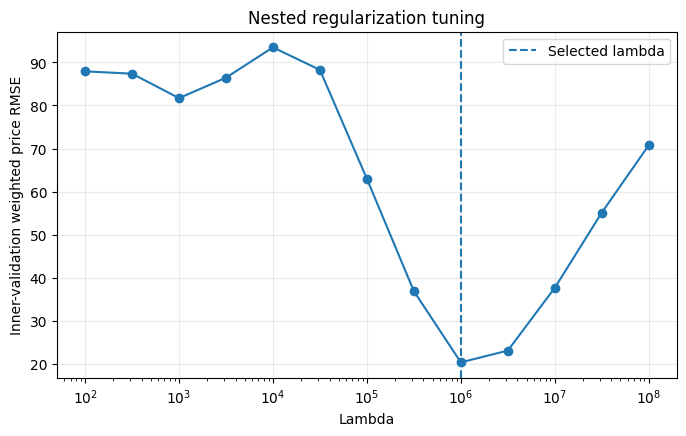

In [7]:
plt.figure(figsize=(8, 4.5))
finite_results = lambda_validation[
    np.isfinite(lambda_validation["validation_weighted_price_rmse"])
]
plt.semilogx(
    finite_results["lambda"],
    finite_results["validation_weighted_price_rmse"],
    marker="o",
)
plt.axvline(selected_lambda, linestyle="--", label="Selected lambda")
plt.xlabel("Lambda")
plt.ylabel("Inner-validation weighted price RMSE")
plt.title("Nested regularization tuning")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 3. Phase B — nonlinear operator fit and held-out comparison

The selected $\lambda$ is frozen. The operator model is estimated using all
840 outer training quotes and refined with three damped Gauss–Newton steps.
SSVI is also frozen after fitting the same outer training set.

In [8]:
if RUN_STAGE_13:
    phase_b = subprocess.run(
        [
            sys.executable,
            str(project_root / "scripts" / "13b_fit_compare_real_market.py"),
            "--project-root",
            str(project_root),
        ],
        check=True,
        capture_output=True,
        text=True,
    )
    print(phase_b.stdout)
else:
    print("Using bundled validated Stage 13 comparison outputs.")


Using bundled validated Stage 13 comparison outputs.


In [9]:
output_directory = project_root / "outputs" / "stage_13"
metrics = pd.read_csv(output_directory / "held_out_model_metrics.csv")
predictions = pd.read_csv(
    output_directory / "real_market_predictions.csv",
    parse_dates=["quote_date", "expiration"],
)
local_surfaces = np.load(output_directory / "local_volatility_surfaces.npz")
operator_history = pd.read_csv(output_directory / "operator_history.csv")

metrics

,method,split,number_of_quotes,price_rmse,price_mae,weighted_price_rmse,mean_gaussian_nll,inside_bid_ask_fraction,implied_volatility_rmse,implied_volatility_mae
0,ssvi,test,203,1.170278,0.833082,5.236565,13.387482,0.266010,0.003709,0.001983
1,operator,test,203,3.202430,1.628906,8.595422,36.617314,0.211823,0.005459,0.002840
2,ssvi,train,840,1.188946,0.850618,5.307157,13.735586,0.282143,0.004460,0.002128
3,operator,train,840,3.226456,1.642785,8.920392,39.439326,0.213095,0.006990,0.003116


## 4. Held-out result

A weighted price RMSE of one would mean that typical errors are approximately
one quoted half-spread. Values above one indicate that the smooth model does
not explain all cross-sectional market detail at the stated quote-noise scale.

The result must be stated honestly: on this SPX snapshot, SSVI gives the better
held-out pricing fit.

In [10]:
test_metrics = metrics[metrics["split"] == "test"].set_index("method")

print(
    "SSVI held-out weighted price RMSE:",
    float(test_metrics.loc["ssvi", "weighted_price_rmse"]),
)
print(
    "Operator held-out weighted price RMSE:",
    float(test_metrics.loc["operator", "weighted_price_rmse"]),
)
print(
    "SSVI held-out implied-volatility RMSE:",
    float(test_metrics.loc["ssvi", "implied_volatility_rmse"]),
)
print(
    "Operator held-out implied-volatility RMSE:",
    float(test_metrics.loc["operator", "implied_volatility_rmse"]),
)

SSVI held-out weighted price RMSE: 5.236564515899169
Operator held-out weighted price RMSE: 8.59542160407843
SSVI held-out implied-volatility RMSE: 0.0037093383634388
Operator held-out implied-volatility RMSE: 0.0054589576905899


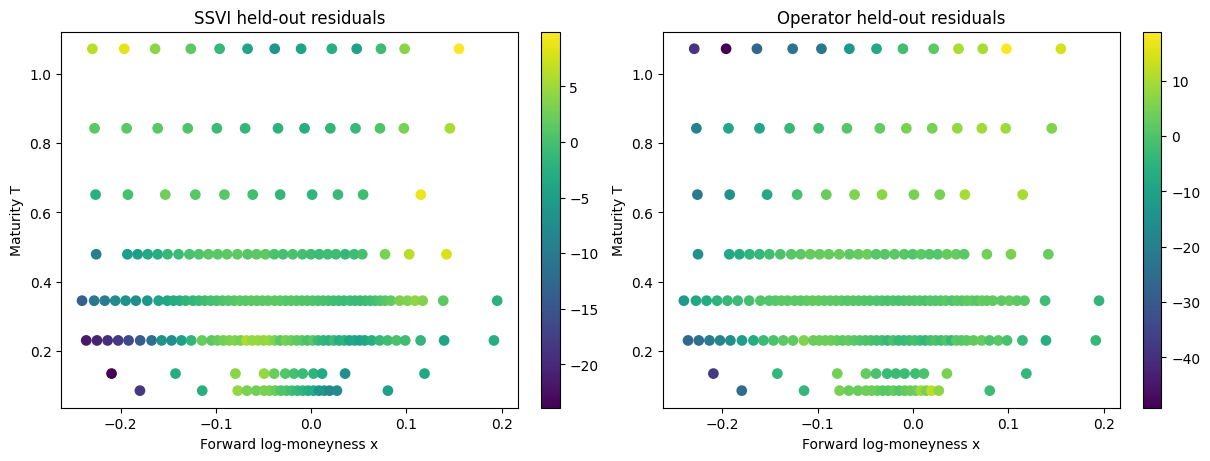

In [11]:
test_predictions = predictions[predictions["is_test"]].copy()

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for axis, method, title in [
    (axes[0], "ssvi", "SSVI held-out residuals"),
    (axes[1], "operator", "Operator held-out residuals"),
]:
    standardized = (
        test_predictions[f"{method}_price"]
        - test_predictions["observed_call_price"]
    ) / test_predictions["noise_standard_deviation"]
    scatter = axis.scatter(
        test_predictions["log_moneyness"],
        test_predictions["maturity"],
        c=standardized,
        s=45,
    )
    figure.colorbar(scatter, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Forward log-moneyness x")
    axis.set_ylabel("Maturity T")
plt.show()

## 5. Structural local-volatility comparison

There is no observed true market local-volatility surface, so the following
plots are structural diagnostics rather than accuracy measurements.

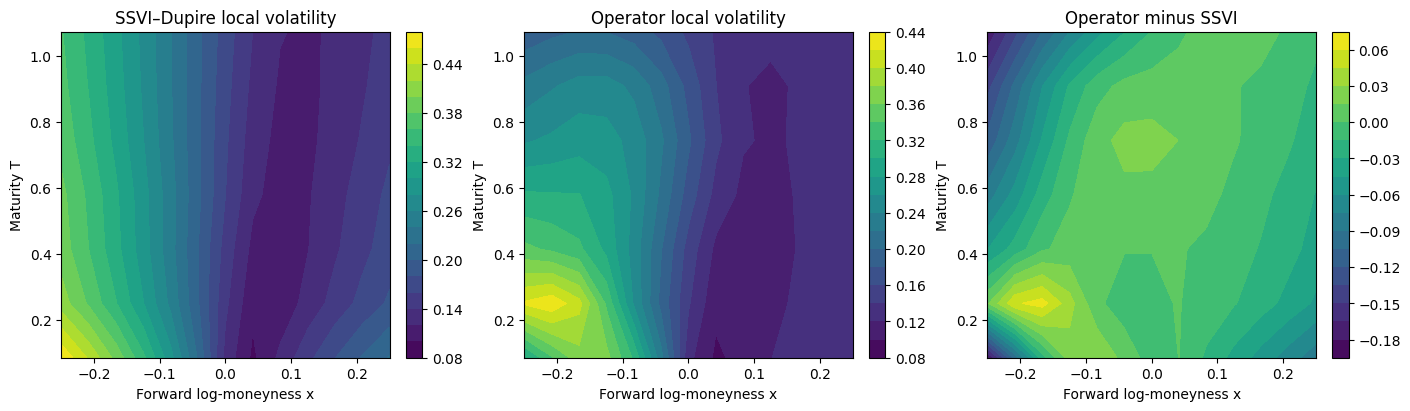

In [12]:
calibration_T = local_surfaces["calibration_maturities"]
calibration_x = local_surfaces["calibration_log_moneyness"]
ssvi_local_volatility = local_surfaces["ssvi_local_volatility"]
operator_local_volatility = local_surfaces["operator_local_volatility"]

figure, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for axis, surface, title in [
    (axes[0], ssvi_local_volatility, "SSVI–Dupire local volatility"),
    (axes[1], operator_local_volatility, "Operator local volatility"),
    (
        axes[2],
        operator_local_volatility - ssvi_local_volatility,
        "Operator minus SSVI",
    ),
]:
    contour = axis.contourf(calibration_x, calibration_T, surface, levels=20)
    figure.colorbar(contour, ax=axis)
    axis.set_xlabel("Forward log-moneyness x")
    axis.set_ylabel("Maturity T")
    axis.set_title(title)
plt.show()

## Stage 13 result

This is the first genuine out-of-sample market comparison.

For this 25 August 2023 SPX panel, SSVI is more accurate on the held-out quotes
than the current operator calibration. That does not contradict the synthetic
bump result: the market snapshot appears sufficiently smooth for the
low-dimensional SSVI representation to be effective.

Stage 14 therefore returns to a controlled known-truth experiment and tests all
methods on a more realistic multi-feature local-volatility surface.